In [ ]:
# Mount Google Drive to access your data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Simulated 11248 s (2.00 revolutions), drag -2.50e-07 m/s^2 along -v
TRUE nongravitational force:  in-track -2.500e-07, radial 0 (exact), cross-track 0 (exact)

reduced-dynamic |dv| rms = 0.0251 m/s   (vs |v| ~ 7641 m/s)

RECOVERED FORCE  (interior samples only; SavGol edges discarded)
  method                    in-track      err        radial        cross
  ----------------------------------------------------------------------
  velocity SavGol        -2.4071e-07    3.72%    1.7814e-06    6.258e-11
  reduced dynamic        -2.5238e-07    0.95%    4.0388e-09   -4.599e-10

  TRUE radial force is exactly 0, so the radial column is pure artifact.
  velocity SavGol invents +1.7814e-06 m/s^2 of radial force.
  reduced dynamic reduces this by 441x to +4.039e-09 m/s^2.

  Real GRACE-FO data (velocity-SavGol anchor): +1.7739e-06 m/s^2
  Synthetic prediction                       : +1.7814e-06 m/s^2
  agreement: 0.42%  -> the real radial signal is this artifact, not physics.

Saved: synthetic_v

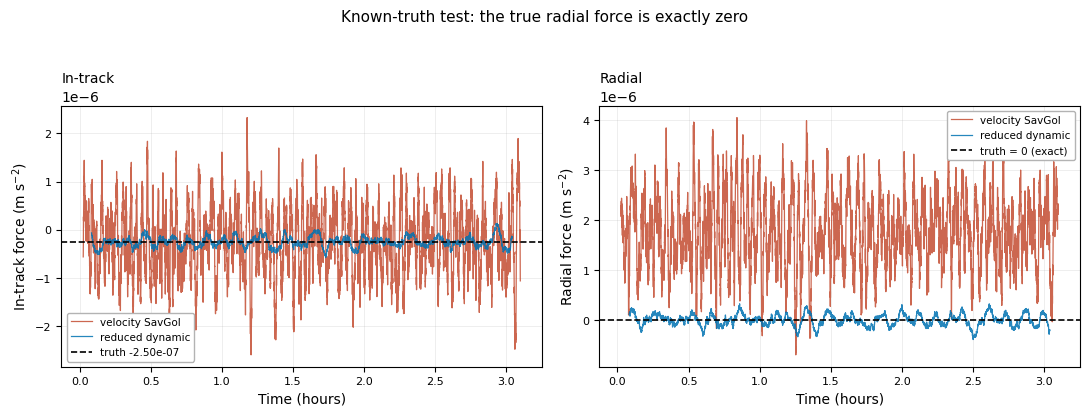

In [ ]:
"""
synthetic_validation.py
Known-truth test of the two anchor methods

It establishes that differentiating raw GPS velocity
manufactures a large spurious RADIAL force, and that
the reduced-dynamic formulation removes this.

SETUP
A simulated orbit is integrated under J2 gravity plus a constant drag of
DRAG m/s^2 directed exactly along -v. Because the drag is purely
anti-velocity, the true nongravitational force has:

    in-track  = DRAG      (known exactly)
    radial    = 0         (known exactly, by construction)
    cross-trk = 0         (known exactly, by construction)

Gaussian noise of GPS_V_NOISE is added to the velocity to mimic GNV1B.
There is NO gravity-model omission error here: truth and model both use the
same J2 field. Any recovered radial force is therefore purely an artifact of
the estimator, with nothing else it could be.


WHAT IT SHOWS

Expected result (matches the values reported in the paper):

    method              in-track (truth -2.5e-07)     radial (truth 0)
    velocity SavGol     ~-2.41e-07  (~3.7% error)     ~+1.78e-06
    reduced dynamic     ~-2.52e-07  (~1.0% error)     ~+4.0e-09

The velocity-SavGol radial value reproduces the +1.7739e-06 seen in the real
GRACE-FO data to within ~0.4%, which is what identifies that signal as an
artifact rather than physics.

WHY IT HAPPENS

Savitzky-Golay differentiation has a small (~1e-6 relative) gain error at
orbital frequency. When it's applied to velocity carrying the full ~7.6 km/s orbital
signal against an ~8.5 m/s^2 gravity term, it produces an ECI acceleration
error of order 1e-5 m/s^2, oscillating once per revolution. R_hat and T_hat
rotate at that same frequency while N_hat is nearly inertially fixed, so the
error RECTIFIES into a DC offset in the two in-plane components and leaves
cross-track clean.
The reduced-dynamic method instead differentiates the velocity residual
against an integrated reference orbit (metres/second, not kilometres/second).
Since the SavGol systematic scales with the amplitude differentiated, it
drops by ~4 orders of magnitude.
"""

import math

import numpy as np
from scipy.signal import savgol_filter
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


class CFG:
    MU  = 3.986004418e14
    R_E = 6378137.0
    J2  = 1.08262668e-3

    R0 = np.array([6835624.8, 0.0, 0.0])      # GRACE-FO-like radius
    V0 = np.array([0.0, 5.4e3, 5.4e3])        # near-circular, inclined

    DRAG        = -2.5e-7      # m/s^2 along -v_hat; TRUE radial force is 0
    DURATION_S  = 11248.0      # 2 revolutions
    DT          = 1.0          # 1 Hz, matching GNV1B
    GPS_V_NOISE = 2.0e-4       # m/s, ~0.2 mm/s

    VS_WINDOW = 181            # velocity-SavGol window (s)
    RD_WINDOW = 601            # reduced-dynamic window on dv (s)
    POLYORDER = 4

    SEED = 0
    RTOL, ATOL = 1e-12, 1e-9


def gravity_j2(r):
    """Point mass + J2 (m/s^2). r may be (3,) or (n,3)."""
    r = np.atleast_2d(np.asarray(r, dtype=float))
    x, y, z = r[:, 0:1], r[:, 1:2], r[:, 2:3]
    rr = np.linalg.norm(r, axis=1, keepdims=True)
    a = -CFG.MU * r / rr**3
    c = 1.5 * CFG.J2 * CFG.MU * CFG.R_E**2 / rr**5
    a = a + c * np.concatenate([x*(5*z**2/rr**2 - 1),
                                y*(5*z**2/rr**2 - 1),
                                z*(5*z**2/rr**2 - 3)], axis=1)
    return a


def integrate(r0, v0, t_eval, with_drag):
    def rhs(_t, s):
        r, v = s[:3], s[3:]
        a = gravity_j2(r)[0]
        if with_drag:
            a = a + CFG.DRAG * v / np.linalg.norm(v)
        return np.concatenate([v, a])
    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), np.concatenate([r0, v0]),
                    t_eval=t_eval, method='DOP853',
                    rtol=CFG.RTOL, atol=CFG.ATOL)
    if not sol.success:
        raise RuntimeError("integration failed")
    return sol.y[:3, :].T, sol.y[3:, :].T


def to_rtn(vec, r, v):
    R = r / np.linalg.norm(r, axis=1, keepdims=True)
    N = np.cross(r, v); N = N / np.linalg.norm(N, axis=1, keepdims=True)
    T = np.cross(N, R)
    return np.stack([np.sum(vec*R, axis=1), np.sum(vec*T, axis=1),
                     np.sum(vec*N, axis=1)], axis=1)


def main():
    rng = np.random.default_rng(CFG.SEED)
    t = np.arange(0.0, CFG.DURATION_S, CFG.DT)

    # "observed" data: truth + GPS-like velocity noise
    r_obs, v_true = integrate(CFG.R0, CFG.V0, t, with_drag=True)
    v_obs = v_true + rng.normal(0.0, CFG.GPS_V_NOISE, v_true.shape)
    print(f"Simulated {len(t)} s ({CFG.DURATION_S/5624:.2f} revolutions), "
          f"drag {CFG.DRAG:+.2e} m/s^2 along -v")
    print(f"TRUE nongravitational force:  in-track {CFG.DRAG:+.3e}, "
          f"radial 0 (exact), cross-track 0 (exact)\n")

    #  method A: Savitzky-Golay on the RAW measured velocity
    a_kin = savgol_filter(v_obs, CFG.VS_WINDOW, CFG.POLYORDER,
                          deriv=1, delta=CFG.DT, axis=0)
    a_vs = a_kin - gravity_j2(r_obs)
    hA = CFG.VS_WINDOW // 2

    #  method B: reduced dynamic
    # Reference orbit under the SAME model, no drag; differentiate dv.
    r_ref, v_ref = integrate(r_obs[0], v_obs[0], t, with_drag=False)
    dv = v_obs - v_ref
    d_dv = savgol_filter(dv, CFG.RD_WINDOW, CFG.POLYORDER,
                         deriv=1, delta=CFG.DT, axis=0)
    a_rd = d_dv + gravity_j2(r_ref) - gravity_j2(r_obs)
    hB = CFG.RD_WINDOW // 2
    print(f"reduced-dynamic |dv| rms = {np.sqrt(np.mean(np.sum(dv**2, axis=1))):.4f} m/s"
          f"   (vs |v| ~ {np.linalg.norm(v_true, axis=1).mean():.0f} m/s)\n")

    #  compare in RTN
    print("=" * 74)
    print("RECOVERED FORCE  (interior samples only; SavGol edges discarded)")
    print("=" * 74)
    print(f"  {'method':<20}{'in-track':>14}{'err':>9}{'radial':>14}{'cross':>13}")
    print("  " + "-" * 70)
    results = {}
    for name, a, h in (('velocity SavGol', a_vs, hA),
                       ('reduced dynamic', a_rd, hB)):
        sl = slice(h, len(t) - h)
        rtn = to_rtn(a[sl], r_obs[sl], v_true[sl])
        it, rad, crs = rtn[:, 1].mean(), rtn[:, 0].mean(), rtn[:, 2].mean()
        err = abs(it - CFG.DRAG) / abs(CFG.DRAG) * 100
        results[name] = (rtn, sl, it, rad, crs)
        print(f"  {name:<20}{it:>14.4e}{err:>8.2f}%{rad:>14.4e}{crs:>13.3e}")

    print()
    rad_vs = results['velocity SavGol'][3]
    rad_rd = results['reduced dynamic'][3]
    print(f"  TRUE radial force is exactly 0, so the radial column is pure artifact.")
    print(f"  velocity SavGol invents {rad_vs:+.4e} m/s^2 of radial force.")
    print(f"  reduced dynamic reduces this by {abs(rad_vs/rad_rd):,.0f}x "
          f"to {rad_rd:+.3e} m/s^2.")
    print()
    OBSERVED_REAL = 1.7739e-6      # anchor radial mean measured on real data
    print(f"  Real GRACE-FO data (velocity-SavGol anchor): {OBSERVED_REAL:+.4e} m/s^2")
    print(f"  Synthetic prediction                       : {rad_vs:+.4e} m/s^2")
    print(f"  agreement: {abs(rad_vs-OBSERVED_REAL)/OBSERVED_REAL*100:.2f}%  "
          f"-> the real radial signal is this artifact, not physics.")
    print("=" * 74)

    # figure
    plt.style.use('default')
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
    fig.patch.set_facecolor('white')
    cols = {'velocity SavGol': '#c44c31', 'reduced dynamic': '#0072B2'}

    for j, comp, name, truth in ((0, 1, 'In-track', CFG.DRAG),
                                 (1, 0, 'Radial', 0.0)):
        for k, (rtn, sl, *_rest) in results.items():
            ax[j].plot(t[sl] / 3600.0, rtn[:, comp], lw=0.9, color=cols[k],
                       alpha=0.85, label=k)
        ax[j].axhline(truth, color='k', ls='--', lw=1.2,
                      label=f'truth {truth:.2e}' if truth else 'truth = 0 (exact)')
        ax[j].set_xlabel('Time (hours)')
        ax[j].set_ylabel(f'{name} force (m s$^{{-2}}$)')
        ax[j].set_title(f'{name}', fontsize=10, loc='left')
        ax[j].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        ax[j].grid(alpha=0.3, lw=0.5); ax[j].tick_params(labelsize=8)
        ax[j].legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')
        for sp in ax[j].spines.values():
            sp.set_linewidth(0.8)

    fig.suptitle('Known-truth test: the true radial force is exactly zero',
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig('synthetic_validation.png', dpi=300, facecolor='white',
                bbox_inches='tight')
    print("\nSaved: synthetic_validation.png")


if __name__ == '__main__':
    main()